In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy import signal
from scipy.stats import entropy

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)



In [2]:
fs = 1024
N = 1024

t = np.arange(N) / fs

print("Sampling rate:", fs, "Hz")
print("Number of samples:", N)
print("Signal duration:", N / fs, "seconds")
print("Frequency resolution:", fs / N, "Hz")

Sampling rate: 1024 Hz
Number of samples: 1024
Signal duration: 1.0 seconds
Frequency resolution: 1.0 Hz


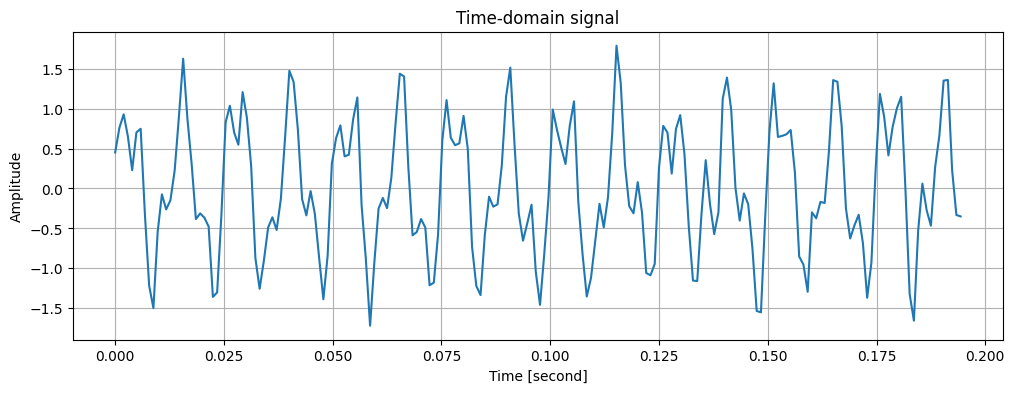

In [3]:
f1 = 80
f2 = 200

phase = np.pi / 4

x = (
    1.0 * np.sin(2 * np.pi * f1 * t)
    + 0.55 * np.sin(2 * np.pi * f2 * t + phase)
    + 0.20 * rng.normal(size=N)
)

plt.figure(figsize=(12, 4))
plt.plot(t[:200], x[:200])

plt.xlabel("Time [second]")
plt.ylabel("Amplitude")
plt.title("Time-domain signal")
plt.grid(True)
plt.show()

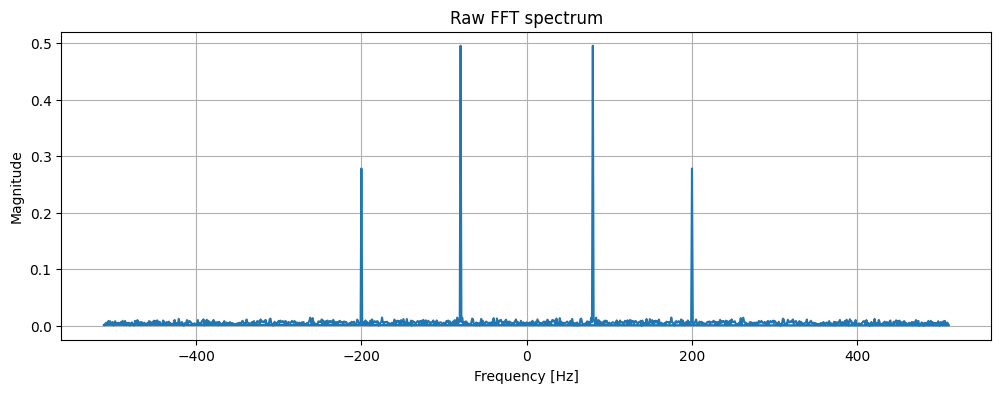

In [4]:
X = np.fft.fft(x)

frequency_axis = np.fft.fftfreq(
    N,
    d=1/fs
)

magnitude = np.abs(X) / N

plt.figure(figsize=(12, 4))
plt.plot(frequency_axis, magnitude)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("Raw FFT spectrum")
plt.grid(True)
plt.show()

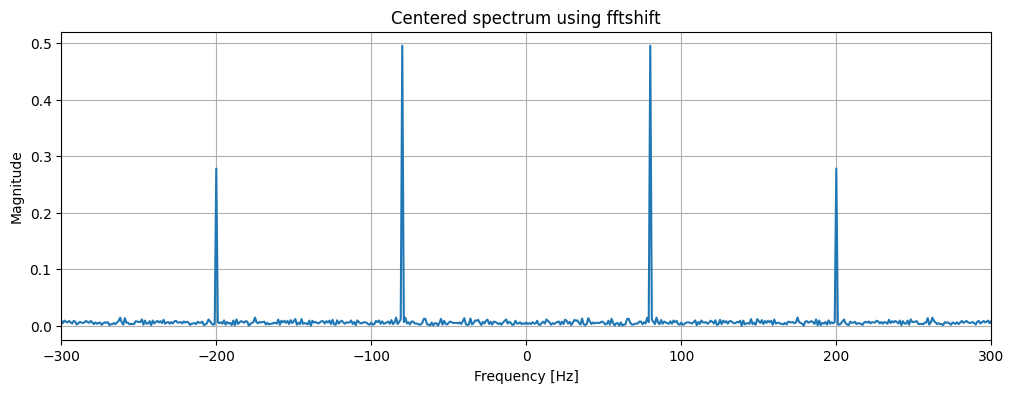

In [5]:
X_shifted = np.fft.fftshift(X)

frequency_shifted = np.fft.fftshift(
    frequency_axis
)

magnitude_shifted = np.abs(X_shifted) / N

plt.figure(figsize=(12, 4))
plt.plot(
    frequency_shifted,
    magnitude_shifted
)

plt.xlim(-300, 300)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("Centered spectrum using fftshift")

plt.grid(True)
plt.show()

In [6]:
top_indices = np.argsort(magnitude_shifted)[-10:][::-1]
dominant_frequencies = frequency_shifted[top_indices]
dominant_magnitudes = magnitude_shifted[top_indices]
dominant_frequencies

array([  80.,  -80.,  200., -200.,  175., -175.,  -84.,   84.,  262.,
       -262.])

In [7]:
dominant_magnitudes

array([0.49504672, 0.49504672, 0.2780477 , 0.2780477 , 0.01468263,
       0.01468263, 0.01447315, 0.01447315, 0.01440947, 0.01440947])

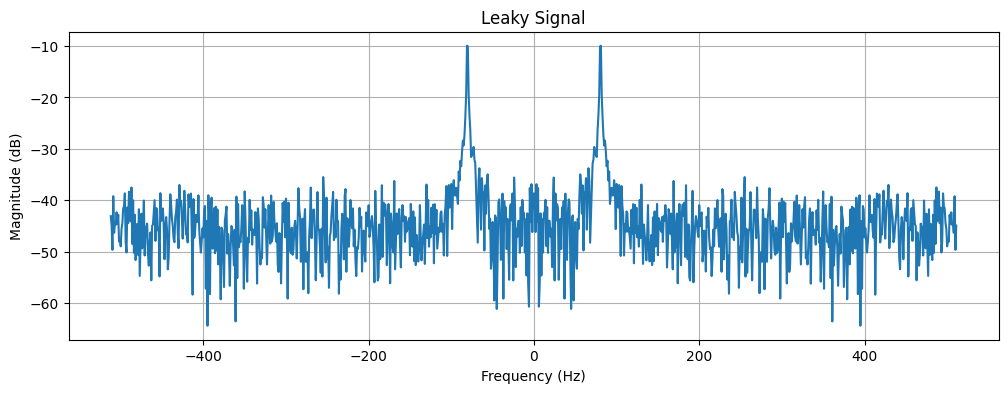

In [8]:
leaky_frequency=80.5 
x_leaky=np.sin(2 * np.pi * leaky_frequency * t) + 0.20 * rng.normal(size=N)
leaky_magnitude = np.abs(np.fft.fftshift(np.fft.fft(x_leaky))) / N
leaky_magnitude_db=20 * np.log10(leaky_magnitude + 1e-12)
plt.figure(figsize=(12, 4))
plt.plot(frequency_shifted, leaky_magnitude_db)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Leaky Signal")
plt.grid(True)
plt.show()

window function 

In [9]:
windows = {
    "Rectangular": signal.windows.boxcar(N),
    "Hann": signal.windows.hann(N),
    "Hamming": signal.windows.hamming(N),
    "Blackman": signal.windows.blackman(N),
    "Kaiser_beta_5": signal.windows.kaiser(N, beta=5),
    "Kaiser_beta_10": signal.windows.kaiser(N, beta=10),
}

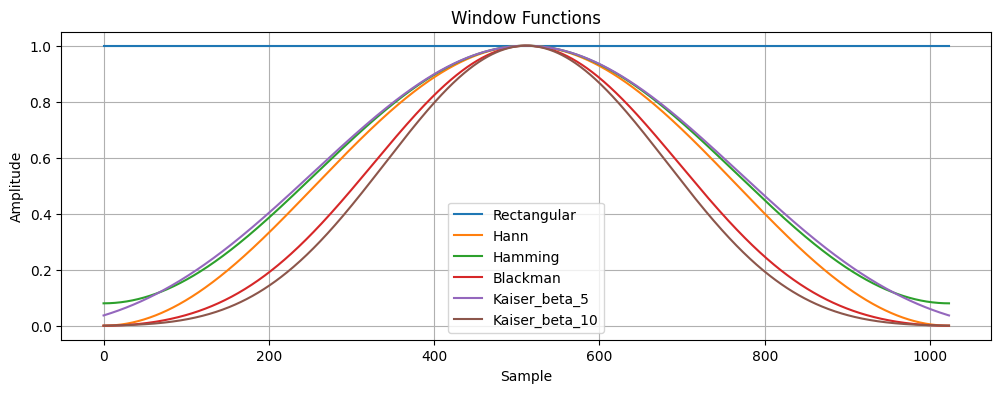

In [10]:
plt.figure(figsize=(12, 4))
for window_name, window in windows.items():
    plt.plot(window, label=window_name)
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Window Functions")
plt.legend()
plt.grid(True)
plt.show()

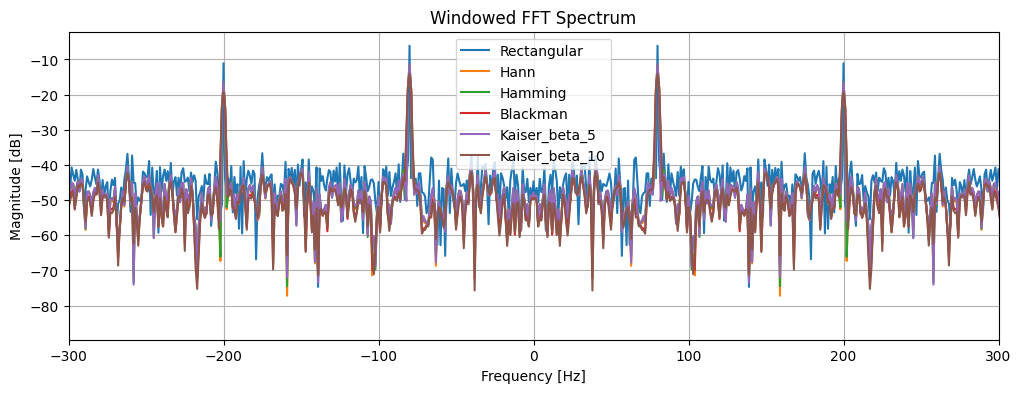

In [11]:
plt.figure(figsize=(12, 4))
for window_name, window in windows.items():
    windowed_signal = x * window
    windowed_magnitude = np.abs(np.fft.fftshift(np.fft.fft(windowed_signal))) / N
    windowed_magnitude_db = 20 * np.log10(windowed_magnitude + 1e-12)
    plt.plot(frequency_shifted, windowed_magnitude_db, label=window_name)
plt.xlim(-300, 300)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Windowed FFT Spectrum")
plt.legend()
plt.grid(True)

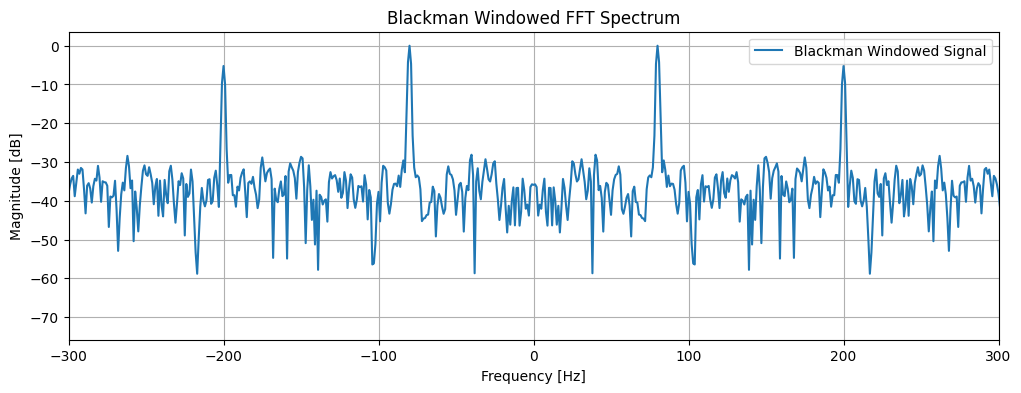

In [12]:
blackman_window=np.blackman(N)
blackman_windowed_signal = x * blackman_window
blackman_windowed_magnitude = np.abs(np.fft.fftshift(np.fft.fft(blackman_windowed_signal))) / N
blackman_windowed_magnitude_db = 20 * np.log10(blackman_windowed_magnitude + 1e-12)
blackman_windowed_magnitude_db -= blackman_windowed_magnitude_db.max()
plt.figure(figsize=(12, 4))
plt.plot(frequency_shifted, blackman_windowed_magnitude_db, label="Blackman Windowed Signal")
plt.xlim(-300, 300)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Blackman Windowed FFT Spectrum")
plt.legend()
plt.grid(True)

kaiser window 

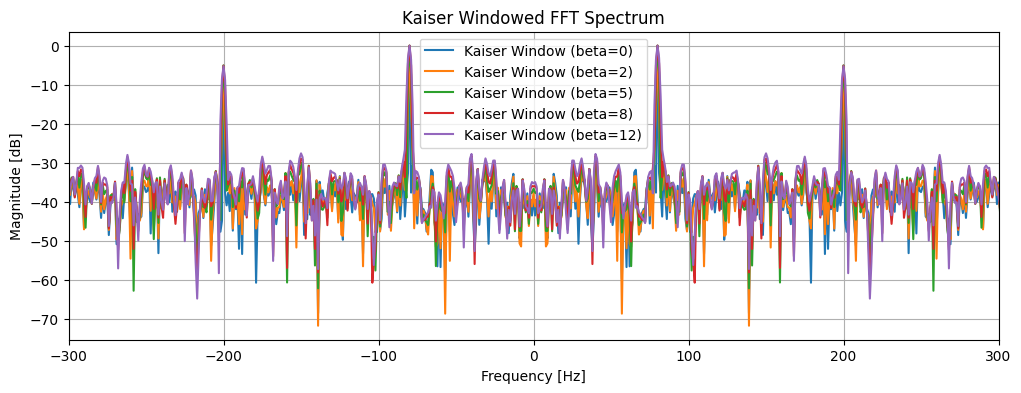

In [13]:
best_values = [0,2,5,8,12]
plt.figure(figsize=(12, 4))
for beta in best_values:
    kaiser_window = signal.windows.kaiser(N, beta=beta)
    kaiser_windowed_signal = x * kaiser_window
    kaiser_windowed_magnitude = np.abs(np.fft.fftshift(np.fft.fft(kaiser_windowed_signal))) / N
    kaiser_windowed_magnitude_db = 20 * np.log10(kaiser_windowed_magnitude + 1e-12)
    kaiser_windowed_magnitude_db -= kaiser_windowed_magnitude_db.max()
    plt.plot(frequency_shifted, kaiser_windowed_magnitude_db, label=f"Kaiser Window (beta={beta})")
plt.xlim(-300, 300)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Kaiser Windowed FFT Spectrum")
plt.legend()
plt.grid(True)

Text(0, 0.5, 'Magnitude [dB]')

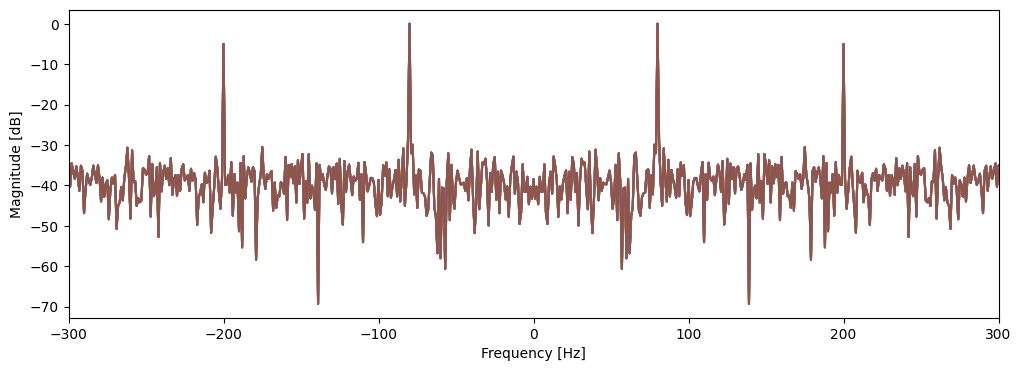

In [14]:
plt.figure(figsize=(12, 4))
for window_name, window in windows.items():
    window_values = np.kaiser(N, beta=0.5)
    windowed_signal = x * window_values
    spectrum=np.fft.fftshift(np.fft.fft(windowed_signal))
    coherent_gain = np.sum(window_values) / N
    windowed_magnitude = np.abs(spectrum) / (N * coherent_gain)
    windowed_magnitude_db = 20 * np.log10(windowed_magnitude + 1e-12)
    windowed_magnitude_db -= windowed_magnitude_db.max()
    plt.plot(frequency_shifted, windowed_magnitude_db, label=window_name)
plt.xlim(-300, 300)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")

zero padding


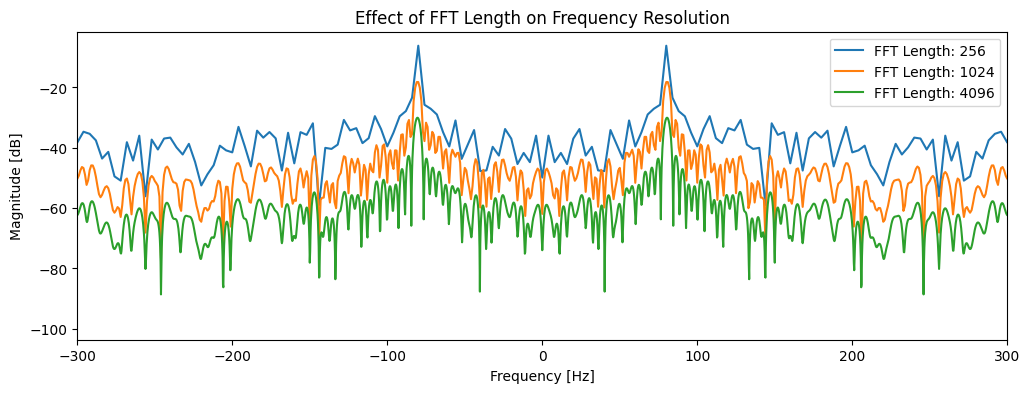

In [15]:
short_N=256
short_signal=x_leaky[:short_N]
fft_series =[256,1024,4096]
plt.figure(figsize=(12, 4))
for N in fft_series:
    short_signal_padded = np.pad(short_signal, (0, N - short_N), 'constant')
    spectrum = np.fft.fftshift(np.fft.fft(short_signal_padded))
    magnitude = np.abs(spectrum) / N
    magnitude_db = 20 * np.log10(magnitude + 1e-12)
    frequency_axis = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))
    plt.plot(frequency_axis, magnitude_db, label=f"FFT Length: {N}")
plt.xlim(-300, 300)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Effect of FFT Length on Frequency Resolution")
plt.legend()

Text(0.5, 1.0, 'Chirp Signal')

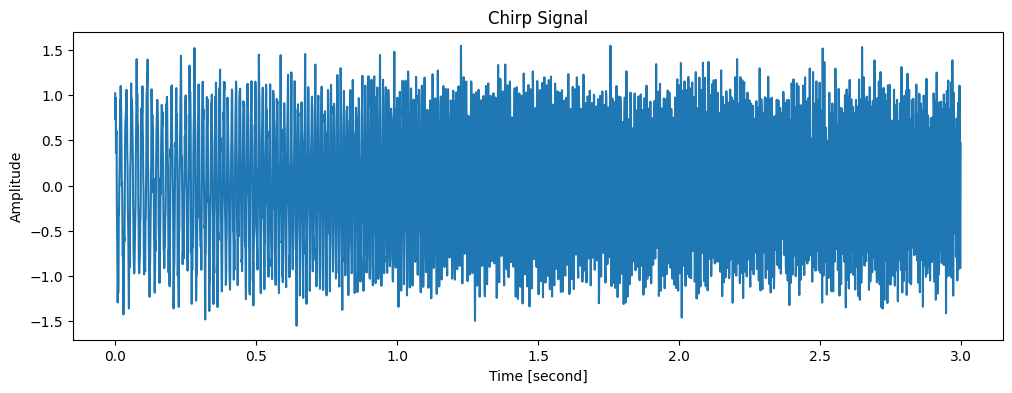

In [16]:
duration = 3.0 
chirp_time=np.arange(0, duration, 1/fs)
chirp_signal = signal.chirp(chirp_time, f0=50, f1=200, t1=duration, method='linear')
chirp_signal+= 0.20 * rng.normal(size=len(chirp_time))
plt.figure(figsize=(12, 4))
plt.plot(chirp_time, chirp_signal)
plt.xlabel("Time [second]")
plt.ylabel("Amplitude")
plt.title("Chirp Signal")

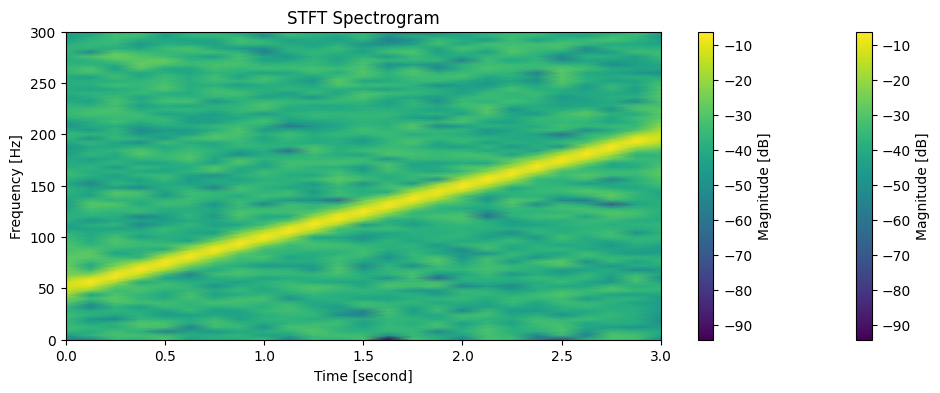

In [17]:
frequency_stft,times_stft,Zxx = signal.stft(chirp_signal, fs=fs, nperseg=256, noverlap=128)
spectrogram_db=20 * np.log10(np.abs(Zxx) + 1e-12)
plt.figure(figsize=(12, 4))
plt.pcolormesh(times_stft, frequency_stft, spectrogram_db, shading='gouraud', cmap='viridis')
plt.colorbar(label='Magnitude [dB]')
plt.xlabel("Time [second]")
plt.ylabel("Frequency [Hz]")
plt.title("STFT Spectrogram")
plt.ylim(0, 300)
plt.colorbar(label='Magnitude [dB]')
plt.show()

In [19]:



def generate_signal(class_name, fs=1024, N=1024, rng=None):
    if rng is None:
        rng = np.random.default_rng(RANDOM_STATE)

    class_name = class_name.strip().lower()
    t = np.arange(N) / fs
    noise = 0.20 * rng.normal(size=N)

    if class_name == "low tone":
        f1 = 80
        f2 = 200
        phase = np.pi / 4

        signal_data = (
            np.sin(2 * np.pi * f1 * t)
            - 0.55 * np.sin(2 * np.pi * f2 * t + phase)
            + noise
        )

    elif class_name == "high tone":
        high_frequency = 300

        signal_data = (
            np.sin(2 * np.pi * high_frequency * t)
            + noise
        )

    elif class_name == "dual tone":
        f1 = 100
        f2 = 250

        signal_data = (
            np.sin(2 * np.pi * f1 * t)
            + 0.7 * np.sin(2 * np.pi * f2 * t)
            + noise
        )

    elif class_name == "chirp":
        start_frequency = rng.uniform(50, 100)
        end_frequency = rng.uniform(150, 250)

        chirp_signal = signal.chirp(
            t,
            f0=start_frequency,
            f1=end_frequency,
            t1=t[-1] if N > 1 else 1 / fs,
            method="linear"
        )

        signal_data = chirp_signal + noise

    elif class_name == "noise":
        noise_std = rng.uniform(0.1, 0.5)
        signal_data = rng.normal(
            loc=0,
            scale=noise_std,
            size=N
        )

    else:
        raise ValueError(f"Unknown class name: {class_name}")

    return signal_data

band power function 

In [25]:
import numpy as np


def calculate_band_power(
    frequencies,
    psd,
    lower_frequency,
    upper_frequency
):
    frequencies = np.asarray(frequencies)
    psd = np.asarray(psd)

    if frequencies.shape != psd.shape:
        raise ValueError("frequencies এবং psd-এর shape একই হতে হবে")

    if lower_frequency > upper_frequency:
        raise ValueError(
            "lower_frequency অবশ্যই upper_frequency-এর চেয়ে ছোট হতে হবে"
        )

    band_mask = (
        (frequencies >= lower_frequency)
        & (frequencies <= upper_frequency)
    )

    if not np.any(band_mask):
        return 0.0

    band_power = np.trapz(
        psd[band_mask],
        frequencies[band_mask]
    )

    return float(band_power)

In [26]:
def extract_features(signal_data, fs=1024):
    frequencies, psd = signal.welch(signal_data, fs=fs, nperseg=256)

    band_power_0_100 = calculate_band_power(frequencies, psd, 0, 100)
    band_power_100_200 = calculate_band_power(frequencies, psd, 100, 200)
    band_power_200_300 = calculate_band_power(frequencies, psd, 200, 300)

    total_power = np.trapz(psd, frequencies)
    entropy_value = entropy(psd)

    features = {
        "band_power_0_100": band_power_0_100,
        "band_power_100_200": band_power_100_200,
        "band_power_200_300": band_power_200_300,
        "total_power": total_power,
        "entropy": entropy_value
    }

    return features

In [27]:
sample_signal = generate_signal("low tone", fs=1024, N=1024, rng=rng)
features = extract_features(sample_signal, fs=1024)
print("Extracted Features:")
for feature_name, feature_value in features.items():
    print(f"{feature_name}: {feature_value:.6f}")

Extracted Features:
band_power_0_100: 0.497048
band_power_100_200: 0.080427
band_power_200_300: 0.082684
total_power: 0.677345
entropy: 1.820112


In [28]:
class_names = ["low tone", "high tone", "dual tone", "chirp", "noise"]
samples_per_class = 100
feature_rows = []
labels = []
raw_signals = []
dataset_rng = np.random.default_rng(RANDOM_STATE)
for class_name in class_names:
    for _ in range(samples_per_class):
        signal_data = generate_signal(class_name, fs=1024, N=1024, rng=dataset_rng)
        features = extract_features(signal_data, fs=1024)
        feature_rows.append(features)
        labels.append(class_name)
        raw_signals.append(signal_data)
        
x_features_df = pd.DataFrame(feature_rows)
y_labels_series = pd.Series(labels, name="class_label")
print("Feature DataFrame:")
print(x_features_df.head())
print("\nLabels Series:")
print(y_labels_series.head())

Feature DataFrame:
   band_power_0_100  band_power_100_200  band_power_200_300  total_power  \
0          0.506657            0.083049            0.081159     0.684948   
1          0.492165            0.089289            0.087108     0.686581   
2          0.509334            0.084666            0.086451     0.696026   
3          0.497255            0.088081            0.087119     0.686985   
4          0.515559            0.082759            0.084070     0.699929   

    entropy  
0  1.811410  
1  1.855094  
2  1.828212  
3  1.800623  
4  1.807741  

Labels Series:
0    low tone
1    low tone
2    low tone
3    low tone
4    low tone
Name: class_label, dtype: object


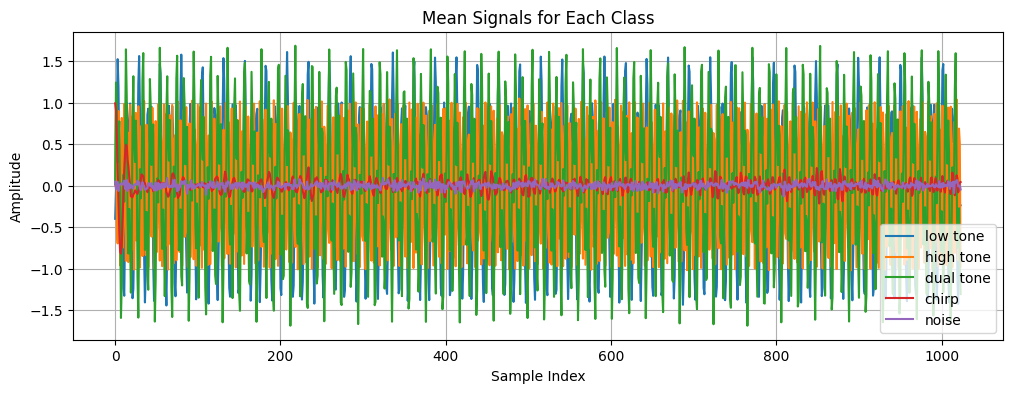

In [29]:
plt.figure(figsize=(12, 4))
for class_name in class_names:
    class_signals = [
        raw_signals[i]
        for i in range(len(raw_signals))
        if labels[i] == class_name
    ]
    mean_signal = np.mean(class_signals, axis=0)
    plt.plot(mean_signal, label=class_name)
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.title("Mean Signals for Each Class")
    plt.legend()
plt.grid(True)
plt.show()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    x_features_df,
    y_labels_series,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_labels_series
)
print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 400
Test set size: 100


In [31]:
model=Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE,n_estimators=100,class_weight="balanced",n_jobs=-1)) ])

In [32]:
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


In [34]:
y_predictions = model.predict(X_test)
print(classification_report(y_test, y_predictions,digits=4))

              precision    recall  f1-score   support

       chirp     1.0000    1.0000    1.0000        20
   dual tone     1.0000    1.0000    1.0000        20
   high tone     1.0000    1.0000    1.0000        20
    low tone     1.0000    1.0000    1.0000        20
       noise     1.0000    1.0000    1.0000        20

    accuracy                         1.0000       100
   macro avg     1.0000    1.0000    1.0000       100
weighted avg     1.0000    1.0000    1.0000       100



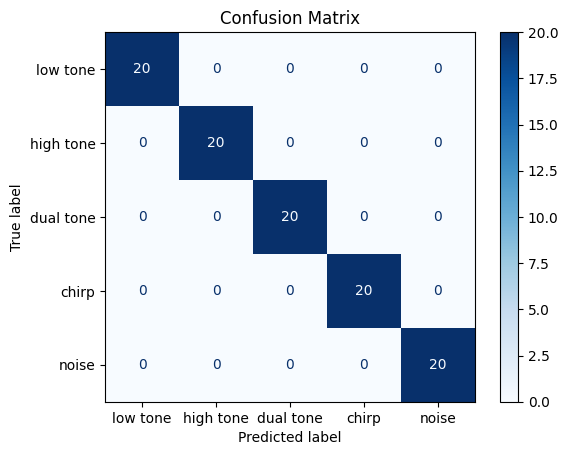

In [35]:
confusion = confusion_matrix(y_test, y_predictions, labels=class_names)
display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=class_names)
display.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [36]:
permutation_importance_result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="neg_log_loss"
)
importance_df = pd.DataFrame({
    "feature": x_features_df.columns,
    "importance_mean": permutation_importance_result.importances_mean,
    "importance_std": permutation_importance_result.importances_std
}).sort_values(by="importance_mean", ascending=False)
print("Feature Importance:")
print(importance_df)

Feature Importance:
              feature  importance_mean  importance_std
1  band_power_100_200         0.069333        0.016720
4             entropy         0.000667        0.002494
0    band_power_0_100         0.000000        0.000000
2  band_power_200_300         0.000000        0.000000
3         total_power         0.000000        0.000000


Text(0.5, 1.0, 'Permutation Feature Importance')

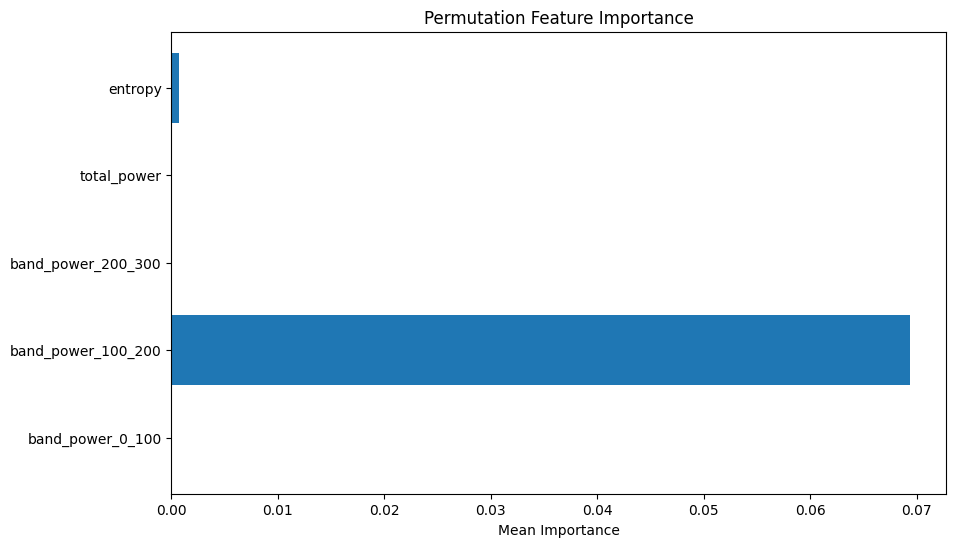

In [37]:
permutation_importance_result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="neg_log_loss"
)
importance_plot_df = importance_df.sort_values(
    by="importance_mean", ascending=True
)
plt.figure(figsize=(10, 6))
plt.barh(
    importance_plot_df["feature"],
    importance_plot_df["importance_mean"]
)
plt.xlabel("Mean Importance (neg_log_loss)")
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()

Top 3 Features:
band_power_100_200
entropy
band_power_0_100


Text(0.5, 1.0, 'Top 3 Feature Importance')

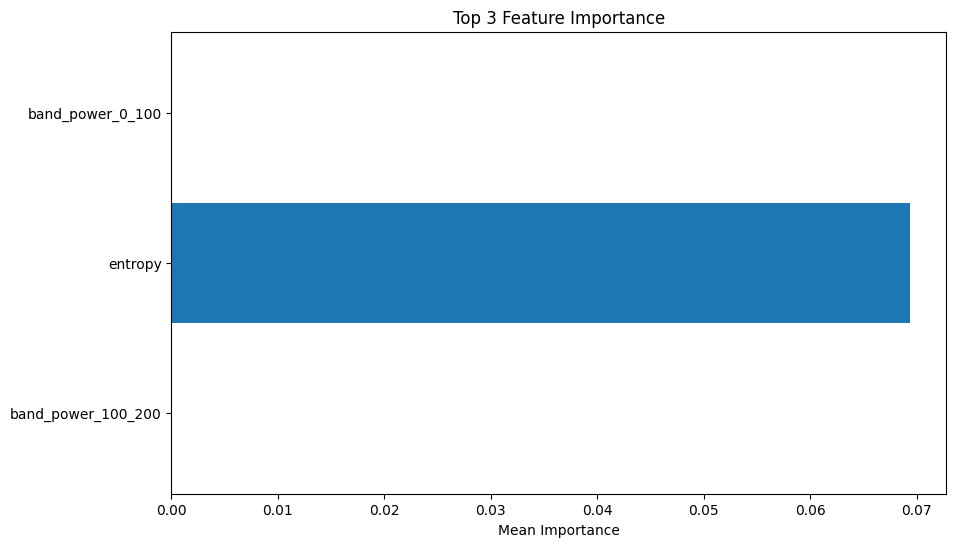

In [38]:
top_features_df = importance_df.head(3)
top_features = top_features_df["feature"].tolist()
print("Top 3 Features:")
for feature in top_features:
    print(feature)  
plt.figure(figsize=(10, 6))
plt.barh(
    top_features_df["feature"],
    top_features_df["importance_mean"]
)
plt.xlabel("Mean Importance (neg_log_loss)")
plt.title("Top 3 Feature Importance")
plt.tight_layout()
plt.show()